# Notebook 5 — Final `test_block` Evaluation
### Detectability-Aware Post-Merger GW Anomaly Screening

---

**This is the terminal, one-time evaluation notebook for this project's frozen design.** It is not a
development notebook. Every threshold, model, hyperparameter, and preprocessing choice used below was
fixed *before* this notebook was written, in `frozen_config.json`, on the basis of `calib_block` and
`train_block` alone. `test_block` is loaded here for the first time in this project's history, is used
exclusively for evaluation, and does not influence any decision made in this notebook.

**Governing rules (from `frozen_config.json` and `PROJECT_SPEC.md` Sec. 11):**

1. `test_block` is loaded only in this notebook.
2. No threshold, model, hyperparameter, or preprocessing choice is changed based on `test_block` results.
3. The frozen configuration is used exactly, with explicit consistency checks against it, not
   re-derivation of decision values.
4. Both conditional (Stage-1 passers only) and end-to-end (all injections) metrics are reported.
5. Per-tau flag rates are reported.
6. Stage-1 pass rates are reported.
7. AUC and low-FPR operating-point results are reported for every method.
8. All outputs and a final consolidated JSON summary are saved.
9. If `test_block` performance differs from the `stage2_val` held-out validation (Notebook 4.5), that
   difference is reported as-is. **This notebook does not tune anything in response to its own results.**

**Frozen design being evaluated:**

| Component | Value |
|---|---|
| Stage 1 score / threshold | `norm_lambda1` / 55.6439 (alpha=0.01) |
| Stage 2 primary | nonlinear LSQ tau_hat, anomaly threshold 3.472 ms |
| Stage 2 secondary | ridge/energy-decay tau_hat, anomaly threshold 4.365 ms |
| Power baseline | logistic regression on total_power_raw, operating threshold 0.3656 |
| Excluded from v1 | simple CNN, AST/Mahalanobis |


In [1]:
# ---------------------------------------------------------------------------
# 0. Installs
# ---------------------------------------------------------------------------
!pip install -q librosa

## 1. Load the frozen configuration


In [2]:
# ---------------------------------------------------------------------------
# 1. Load frozen_config.json -- the single source of truth for this evaluation
# ---------------------------------------------------------------------------
import json
from google.colab import drive; drive.mount('/content/drive')

FROZEN_CONFIG_PATH = '/content/drive/MyDrive/gw_postmerger/frozen_config.json'  # place frozen_config.json alongside this notebook
with open(FROZEN_CONFIG_PATH) as f:
    FROZEN = json.load(f)

assert FROZEN['_meta']['status'] == 'FROZEN', "frozen_config.json does not report status=FROZEN -- stop."
print(f"Loaded frozen configuration (status: {FROZEN['_meta']['status']})")
print(json.dumps(FROZEN, indent=2))

Mounted at /content/drive
Loaded frozen configuration (status: FROZEN)
{
  "_meta": {
    "status": "FROZEN",
    "description": "Frozen Stage-1 + Stage-2 design for the detectability-aware post-merger GW anomaly screening project. Loaded exactly by Notebook5_Final_TestBlock_Evaluation.ipynb -- no threshold, model, hyperparameter, or preprocessing choice in that notebook may be changed based on test_block results.",
    "spec_reference": "PROJECT_SPEC.md, Sec. 10-11"
  },
  "stage1": {
    "score": "norm_lambda1",
    "threshold": 55.6439,
    "alpha": 0.01,
    "calibration_pool": "calib_block",
    "note": "Threshold value confirmed identical across two independent re-derivations (Notebook 4 and Notebook 4.5)."
  },
  "stage2_primary": {
    "method": "nonlinear_lsq_tau_hat",
    "description": "Nonlinear damped-sinusoid least-squares fit (scipy.optimize.curve_fit) on the whitened time-domain window.",
    "anomaly_threshold_ms": 3.472,
    "decision_rule": "flag anomalous if tau_hat

## 2. Setup — `test_block` loaded for the first and only time in this project

`calib_block` and `train_block` are also loaded, to deterministically re-derive the calibration
artifacts (CQT normalization, ridge noise floor, power logistic regression) that feed the frozen
thresholds -- these are pure functions of `calib_block`/`train_block` alone and never touch
`test_block`. Each re-derived value is checked against `frozen_config.json` in Section 3.


In [3]:
# ---------------------------------------------------------------------------
# 2. Imports, config, load Notebook 1 artifacts -- ALL FOUR blocks, test_block for the first time
# ---------------------------------------------------------------------------
import os
import numpy as np
import scipy.sparse
import scipy.sparse.linalg
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import librosa

SEED = 42
rng = np.random.default_rng(SEED)

NB1_DIR = '/content/drive/MyDrive/gw_postmerger/nb1_artifacts'
OUT_DIR = '/content/drive/MyDrive/gw_postmerger/nb5_artifacts'
os.makedirs(OUT_DIR, exist_ok=True)
assert os.path.isdir(NB1_DIR), f"{NB1_DIR} not found -- run Notebook 1 first."

W = FROZEN['whitening_config']
FS = W['fs_hz']
WINDOW_DUR = W['window_dur_s']
N_SAMPLES_WINDOW = int(FS * WINDOW_DUR)
F_LOW = W['f_low_hz']
F_HIGH = W['f_high_hz']
EDGE_TRIM_S = W['edge_trim_s']
PAD_SAMPLES = int(round(EDGE_TRIM_S * FS))
GUARD_S = 8.0
GUARD_SAMPLES = int(round(GUARD_S * FS))

_psd_npz = np.load(os.path.join(NB1_DIR, "estimated_psd.npz"))
psd_freqs, psd_values = _psd_npz["freqs"], _psd_npz["psd"]
assert np.all(np.isfinite(psd_values)) and np.all(psd_values > 0)
_psd_interp = interp1d(psd_freqs, psd_values, bounds_error=False,
                        fill_value=(psd_values[0], psd_values[-1]))

def whiten(data, fs=FS, psd_interp=_psd_interp, f_low=F_LOW, f_high=F_HIGH):
    assert np.all(np.isfinite(data))
    n = len(data)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    passband = (freqs >= f_low) & (freqs <= f_high)
    asd = np.sqrt(psd_interp(freqs[passband]))
    assert np.all(np.isfinite(asd)) and np.all(asd > 0)
    data_fft = np.fft.rfft(data)
    whitened_fft = np.zeros_like(data_fft)
    whitened_fft[passband] = data_fft[passband] / asd
    out = np.fft.irfft(whitened_fft, n=n)
    assert np.all(np.isfinite(out))
    return out

def generate_signal(f_peak, tau, amplitude=1.0, phi=0.0, fs=FS, n_samples=N_SAMPLES_WINDOW):
    t = np.arange(n_samples) / fs
    return amplitude * np.exp(-t / tau) * np.sin(2 * np.pi * f_peak * t + phi)

def compute_snr(h_t, psd_interp=_psd_interp, fs=FS, f_low=F_LOW, f_high=F_HIGH):
    n = len(h_t)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    passband = (freqs >= f_low) & (freqs <= f_high)
    h_fft = np.fft.rfft(h_t) / fs
    df = freqs[1] - freqs[0]
    rho2 = 4.0 * np.sum(np.abs(h_fft[passband])**2 / psd_interp(freqs[passband])) * df
    return np.sqrt(rho2)

def scale_to_snr(h_t, target_snr, psd_interp=_psd_interp, fs=FS):
    base = compute_snr(h_t, psd_interp=psd_interp, fs=fs)
    assert base > 0
    return h_t * (target_snr / base)

# -- Load calib_block and train_block (for calibration-artifact re-derivation) and, for the first and
# only time in this project, test_block. --
_calib_arr = np.load(os.path.join(NB1_DIR, "raw_calib_block_L1.npy"))
_train_arr = np.load(os.path.join(NB1_DIR, "raw_train_block_L1.npy"))
_test_arr = np.load(os.path.join(NB1_DIR, "raw_test_block_L1.npy"))
for _name, _arr in [('calib_block', _calib_arr), ('train_block', _train_arr), ('test_block', _test_arr)]:
    assert np.all(np.isfinite(_arr)), f"{_name}: non-finite values in loaded raw pool!"

_mid = len(_train_arr) // 2
raw_noise_pools = {
    'calib_block': _calib_arr,
    'stage2_calib': _train_arr[: _mid - GUARD_SAMPLES // 2],
    'stage2_val': _train_arr[_mid + GUARD_SAMPLES // 2:],
    'test_block': _test_arr,
}
del _calib_arr, _train_arr, _test_arr

for name, arr in raw_noise_pools.items():
    print(f"{name:14s}: {len(arr)} samples ({len(arr)/FS:.1f}s)")
print("\n*** test_block loaded for the first and only time in this project. ***")

def inject_and_whiten(block_name, f_peak, tau, target_snr, rng=rng,
                       fs=FS, window_samples=N_SAMPLES_WINDOW, pad_samples=PAD_SAMPLES):
    pool = raw_noise_pools[block_name]
    local_len = window_samples + 2 * pad_samples
    start_idx = rng.integers(0, len(pool) - local_len)
    local_noise = pool[start_idx: start_idx + local_len].astype(np.float64)
    local_noise = local_noise - local_noise.mean()
    h_t = generate_signal(f_peak, tau, fs=fs, n_samples=window_samples)
    h_scaled = scale_to_snr(h_t, target_snr, fs=fs)
    injected_local = local_noise.copy()
    injected_local[pad_samples: pad_samples + window_samples] += h_scaled
    whitened_local = whiten(injected_local, fs=fs)
    interior = whitened_local[pad_samples: pad_samples + window_samples]
    assert np.all(np.isfinite(interior))
    return interior, h_scaled, start_idx

def make_noise_only_window(block_name, rng=rng, fs=FS, window_samples=N_SAMPLES_WINDOW,
                            pad_samples=PAD_SAMPLES):
    pool = raw_noise_pools[block_name]
    local_len = window_samples + 2 * pad_samples
    start_idx = rng.integers(0, len(pool) - local_len)
    local_noise = pool[start_idx: start_idx + local_len].astype(np.float64)
    local_noise = local_noise - local_noise.mean()
    whitened_local = whiten(local_noise, fs=fs)
    interior = whitened_local[pad_samples: pad_samples + window_samples]
    assert np.all(np.isfinite(interior))
    return interior, start_idx

calib_block   : 16777216 samples (1024.0s)
stage2_calib  : 8323072 samples (508.0s)
stage2_val    : 8323072 samples (508.0s)
test_block    : 16777216 samples (1024.0s)

*** test_block loaded for the first and only time in this project. ***


## 3. Re-derive calibration artifacts from `calib_block`/`stage2_calib`, verify against frozen config

Every value computed in this section is a deterministic function of `calib_block`/`stage2_calib` alone
(never `test_block`) and is asserted to match `frozen_config.json` before proceeding. A mismatch here
would mean the frozen config is stale or the calibration pipeline drifted -- either way, it must be
resolved before evaluating `test_block`, not silently tolerated.


In [4]:
# ---------------------------------------------------------------------------
# 3. Re-derive and verify calibration artifacts
# ---------------------------------------------------------------------------
CQT = FROZEN['cqt_config']
GRAPH = FROZEN['graph_config']
CQT_FMIN, CQT_N_BINS = CQT['fmin_hz'], CQT['n_bins']
CQT_BINS_PER_OCTAVE, CQT_HOP_LENGTH = CQT['bins_per_octave'], CQT['hop_length']
CQT_BAND_LOW, CQT_BAND_HIGH = CQT['band_low_hz'], CQT['band_high_hz']
GRAPH_FREQ_RADIUS, GRAPH_TIME_RADIUS = GRAPH['freq_radius'], GRAPH['time_radius']

_cqt_all_freqs = librosa.cqt_frequencies(n_bins=CQT_N_BINS, fmin=CQT_FMIN, bins_per_octave=CQT_BINS_PER_OCTAVE)
_cqt_band_mask = (_cqt_all_freqs >= CQT_BAND_LOW) & (_cqt_all_freqs <= CQT_BAND_HIGH)

def compute_cqt_banded(whitened_window, fs=FS, fmin=CQT_FMIN, n_bins=CQT_N_BINS,
                        bins_per_octave=CQT_BINS_PER_OCTAVE, hop_length=CQT_HOP_LENGTH,
                        band_mask=_cqt_band_mask):
    C = librosa.cqt(whitened_window, sr=fs, fmin=fmin, n_bins=n_bins,
                     bins_per_octave=bins_per_octave, hop_length=hop_length)
    return np.abs(C)[band_mask, :]

# -- CQT tile normalization (calib_block) --
N_NORM_SAMPLES = 500
_norm_stack = []
for _ in range(N_NORM_SAMPLES):
    w, _ = make_noise_only_window('calib_block')
    _norm_stack.append(np.log1p(compute_cqt_banded(w)))
_norm_stack = np.stack(_norm_stack, axis=0)
cqt_bin_median = np.median(_norm_stack, axis=0)
cqt_bin_mad = np.median(np.abs(_norm_stack - cqt_bin_median[None, :, :]), axis=0)
cqt_bin_mad_safe = np.maximum(1.4826 * cqt_bin_mad, 1e-6)
del _norm_stack

def normalize_cqt(mag):
    return np.maximum((np.log1p(mag) - cqt_bin_median) / cqt_bin_mad_safe, 0.0)

GRAPH_FREQ_RADIUS_ = GRAPH_FREQ_RADIUS
GRAPH_TIME_RADIUS_ = GRAPH_TIME_RADIUS

def build_tf_graph(tf_map, freq_radius=GRAPH_FREQ_RADIUS_, time_radius=GRAPH_TIME_RADIUS_):
    n_freq, n_time = tf_map.shape
    n = n_freq * n_time
    idx_grid = np.arange(n).reshape(n_freq, n_time)
    rows, cols, data = [], [], []
    for df in range(-freq_radius, freq_radius + 1):
        for dt in range(-time_radius, time_radius + 1):
            if df == 0 and dt == 0:
                continue
            f_src = slice(max(0, -df), n_freq - max(0, df))
            f_dst = slice(max(0, df), n_freq - max(0, -df))
            t_src = slice(max(0, -dt), n_time - max(0, dt))
            t_dst = slice(max(0, dt), n_time - max(0, -dt))
            src_idx = idx_grid[f_src, t_src].reshape(-1)
            dst_idx = idx_grid[f_dst, t_dst].reshape(-1)
            w = (tf_map[f_src, t_src] * tf_map[f_dst, t_dst]).reshape(-1)
            rows.append(src_idx); cols.append(dst_idx); data.append(w)
    rows = np.concatenate(rows); cols = np.concatenate(cols); data = np.concatenate(data)
    return scipy.sparse.csr_matrix((data, (rows, cols)), shape=(n, n))

def leading_eigenvalue(A):
    if A.nnz == 0:
        return 0.0
    try:
        return float(scipy.sparse.linalg.eigsh(A, k=1, which='LA', return_eigenvectors=False)[0])
    except Exception:
        return float(np.linalg.eigvalsh(A.toarray())[-1])

def stage1_statistic(window):
    z_pos = normalize_cqt(compute_cqt_banded(window))
    return leading_eigenvalue(build_tf_graph(z_pos))

def total_power_raw(window):
    return float(compute_cqt_banded(window).sum())

# -- Stage-1 threshold (calib_block) --
N_CALIBRATION = 4000
null_norm_lambda1 = np.empty(N_CALIBRATION)
for i in range(N_CALIBRATION):
    w, _ = make_noise_only_window('calib_block')
    null_norm_lambda1[i] = stage1_statistic(w)
derived_stage1_threshold = np.percentile(null_norm_lambda1, 100 * (1 - FROZEN['stage1']['alpha']))

frozen_stage1_threshold = FROZEN['stage1']['threshold']
print(f"Stage-1 threshold: derived={derived_stage1_threshold:.4f}  frozen={frozen_stage1_threshold:.4f}")
assert abs(derived_stage1_threshold - frozen_stage1_threshold) < 1.0, (
    "Re-derived Stage-1 threshold does not match frozen_config.json -- STOP. Do not proceed with a "
    "mismatched calibration; investigate before evaluating test_block."
)
STAGE1_THRESHOLD = frozen_stage1_threshold  # use the frozen value exactly, per rule 3
print("VERIFIED: matches frozen config within tolerance. Using frozen value.")

def stage1_pass(window):
    return stage1_statistic(window) > STAGE1_THRESHOLD

# -- ridge noise floor (calib_block) --
N_NOISE_FLOOR_SAMPLES = 300
_noise_frame_powers = []
for _ in range(N_NOISE_FLOOR_SAMPLES):
    w, _ = make_noise_only_window('calib_block')
    _noise_frame_powers.append(np.sum(compute_cqt_banded(w)**2, axis=0))
_noise_frame_powers = np.concatenate(_noise_frame_powers)
derived_ridge_floor = np.percentile(_noise_frame_powers,
                                     FROZEN['stage2_secondary']['estimator_params']['noise_floor_stop_percentile'])
del _noise_frame_powers

frozen_ridge_floor = FROZEN['stage2_secondary']['estimator_params']['noise_floor_value']
print(f"\nRidge noise floor: derived={derived_ridge_floor:.2f}  frozen={frozen_ridge_floor:.2f}")
assert abs(derived_ridge_floor - frozen_ridge_floor) / frozen_ridge_floor < 0.05, (
    "Re-derived ridge noise floor does not match frozen_config.json within 5% -- STOP."
)
RIDGE_NOISE_FLOOR = frozen_ridge_floor  # use the frozen value exactly
print("VERIFIED: matches frozen config within tolerance. Using frozen value.")

Stage-1 threshold: derived=55.6439  frozen=55.6439
VERIFIED: matches frozen config within tolerance. Using frozen value.

Ridge noise floor: derived=274565.08  frozen=274565.08
VERIFIED: matches frozen config within tolerance. Using frozen value.


## 4. Stage-2 estimators and the fair power-baseline classifier (unchanged from Notebook 4.5, frozen)

`estimate_tau_ridge` and `estimate_tau_lsq` are copied verbatim -- **no parameter has been changed**. The
power logistic regression is re-fit on `stage2_calib` (never `test_block`) and its resulting operating
threshold is verified against the frozen value, exactly as Section 3 verified the Stage-1/ridge-floor
values.


In [5]:
# ---------------------------------------------------------------------------
# 4. Stage-2 estimators (frozen, unchanged) + power baseline (re-derived, verified)
# ---------------------------------------------------------------------------
_RIDGE_PARAMS = FROZEN['stage2_secondary']['estimator_params']

def estimate_tau_ridge(window, fit_max_frames=_RIDGE_PARAMS['fit_max_frames'],
                        min_frames_for_fit=_RIDGE_PARAMS['min_frames_for_fit'],
                        patience=_RIDGE_PARAMS['patience'], noise_floor=RIDGE_NOISE_FLOOR,
                        fs=FS, hop_length=CQT_HOP_LENGTH):
    mag = compute_cqt_banded(window)
    frame_power = np.sum(mag**2, axis=0)
    times = np.arange(mag.shape[1]) * hop_length / fs
    peak_idx = int(np.argmax(frame_power))
    max_end = min(peak_idx + fit_max_frames, len(frame_power))
    end_idx = max_end
    below_count = 0
    for idx in range(peak_idx + 1, max_end):
        if frame_power[idx] <= noise_floor:
            below_count += 1
            if below_count >= patience:
                end_idx = idx - patience + 1
                break
        else:
            below_count = 0
    fit_idx = np.arange(peak_idx, end_idx)
    if len(fit_idx) < min_frames_for_fit:
        return None
    fit_times = times[fit_idx] - times[peak_idx]
    fit_power = np.maximum(frame_power[fit_idx], 1e-12)
    log_power = np.log(fit_power)
    A = np.vstack([fit_times, np.ones_like(fit_times)]).T
    slope, _ = np.linalg.lstsq(A, log_power, rcond=None)[0]
    if slope >= 0:
        return None
    return -2.0 / slope

def _damped_sinusoid_model(t, A, tau, f, phi):
    return A * np.exp(-t / tau) * np.sin(2 * np.pi * f * t + phi)

def estimate_tau_lsq(window, fs=FS, band_low=CQT_BAND_LOW, band_high=CQT_BAND_HIGH):
    n = len(window)
    t = np.arange(n) / fs
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    band = (freqs >= band_low) & (freqs <= band_high)
    fft_mag = np.abs(np.fft.rfft(window))
    f0_guess = freqs[band][np.argmax(fft_mag[band])] if band.any() else 0.5 * (band_low + band_high)
    A0_guess = np.max(np.abs(window))
    p0 = [A0_guess, 0.01, f0_guess, 0.0]
    bounds = ([0, 1e-4, band_low, -np.pi], [np.inf, 0.5, band_high, np.pi])
    try:
        popt, _ = curve_fit(_damped_sinusoid_model, t, window, p0=p0, bounds=bounds, maxfev=5000)
        return float(popt[1])
    except Exception:
        return None

STANDARD_TAUS_MS = set(FROZEN['evaluation_grid']['standard_taus_ms'])
ANOMALOUS_TAUS_MS = set(FROZEN['evaluation_grid']['anomalous_taus_ms'])
TAU_GRID_MS = FROZEN['evaluation_grid']['tau_grid_ms']
SNR_GRID = FROZEN['evaluation_grid']['snr_grid']
N_PER_CELL = 60  # test_block evaluation sample size per (tau, SNR) cell

# -- Re-derive and verify the power logistic regression + operating threshold (stage2_calib only) --
# IMPORTANT: this must reproduce Notebook 4.5's EXACT calibration recipe -- a full sweep at
# N_PER_CELL=40 per (tau,SNR) cell (1200 draws total), not an ad-hoc smaller resample. A first attempt
# here used N=30/cell as a shortcut and got a materially different threshold (0.7508 vs frozen 0.3656)
# purely from that sample-size mismatch -- 99th-percentile threshold estimates are inherently sensitive
# to sample size (the same small-n instability flagged for Stage-1's alpha=0.001 caveat earlier in this
# project), and reproducing a percentile-based threshold requires reproducing the exact sample size that
# produced it, not just a same-seed prefix of it.
POWER_CALIB_N_PER_CELL = 40  # must match Notebook 4.5's calibration sweep exactly
_calib_power_records = []
for tau_ms in TAU_GRID_MS:
    for snr in SNR_GRID:
        for _ in range(POWER_CALIB_N_PER_CELL):
            f_peak = rng.uniform(1500.0, 4000.0)
            w, _, _ = inject_and_whiten('stage2_calib', f_peak=f_peak, tau=tau_ms / 1000.0,
                                         target_snr=float(snr))
            if stage1_pass(w):
                _calib_power_records.append({'tau_ms': tau_ms, 'is_anomalous': tau_ms in ANOMALOUS_TAUS_MS,
                                              'total_power_raw': total_power_raw(w)})

X_power_calib = np.array([[r['total_power_raw']] for r in _calib_power_records])
y_anom_calib = np.array([r['is_anomalous'] for r in _calib_power_records]).astype(int)
power_clf = LogisticRegression().fit(X_power_calib, y_anom_calib)

_std_calib = [r for r in _calib_power_records if r['tau_ms'] in STANDARD_TAUS_MS]
_std_probs_calib = power_clf.predict_proba(np.array([[r['total_power_raw']] for r in _std_calib]))[:, 1]
derived_power_threshold = np.percentile(_std_probs_calib, 99.0)

frozen_power_threshold = FROZEN['power_baseline']['operating_threshold_probability']
print(f"Power operating threshold: derived={derived_power_threshold:.4f}  frozen={frozen_power_threshold:.4f}")
assert abs(derived_power_threshold - frozen_power_threshold) < 0.05, (
    "Re-derived power operating threshold does not match frozen_config.json within tolerance -- STOP."
)
POWER_THRESHOLD = frozen_power_threshold  # use the frozen value exactly
print("VERIFIED: matches frozen config within tolerance. Using frozen value.")

TAU_THRESHOLDS = {
    'tau_hat_lsq': FROZEN['stage2_primary']['anomaly_threshold_ms'] / 1000.0,
    'tau_hat_ridge': FROZEN['stage2_secondary']['anomaly_threshold_ms'] / 1000.0,
}

def flag_ridge(r):
    return r.get('tau_hat_ridge') is not None and r['tau_hat_ridge'] < TAU_THRESHOLDS['tau_hat_ridge']

def flag_lsq(r):
    return r.get('tau_hat_lsq') is not None and r['tau_hat_lsq'] < TAU_THRESHOLDS['tau_hat_lsq']

def flag_power(r):
    if r.get('total_power_raw') is None:
        return False
    prob = power_clf.predict_proba([[r['total_power_raw']]])[0, 1]
    return prob > POWER_THRESHOLD


Power operating threshold: derived=0.3656  frozen=0.3656
VERIFIED: matches frozen config within tolerance. Using frozen value.


## 5. FINAL EVALUATION — `test_block`, once

This is the only cell in this notebook (or this project) that evaluates `test_block`. The `(tau, SNR)`
grid and `N_PER_CELL` match the frozen evaluation grid. No threshold used here was fit on this data.


In [6]:
# ---------------------------------------------------------------------------
# 5. FINAL test_block evaluation
# ---------------------------------------------------------------------------
test_records = []
for tau_ms in TAU_GRID_MS:
    for snr in SNR_GRID:
        for _ in range(N_PER_CELL):
            f_peak = rng.uniform(1500.0, 4000.0)
            w, _, _ = inject_and_whiten('test_block', f_peak=f_peak, tau=tau_ms / 1000.0,
                                         target_snr=float(snr))
            passed = stage1_pass(w)
            rec = {'tau_ms': tau_ms, 'snr': snr, 'is_anomalous': tau_ms in ANOMALOUS_TAUS_MS,
                   'stage1_pass': bool(passed)}
            if passed:
                rec['tau_hat_ridge'] = estimate_tau_ridge(w)
                rec['tau_hat_lsq'] = estimate_tau_lsq(w)
                rec['total_power_raw'] = total_power_raw(w)
            test_records.append(rec)
    print(f"  tau={tau_ms:3d}ms done")

with open(os.path.join(OUT_DIR, 'test_block_records.json'), 'w') as f:
    json.dump(test_records, f, indent=1)
print(f"\nSaved -> {OUT_DIR}/test_block_records.json")
print("\n*** test_block evaluation complete. This data is not re-used for any further fitting. ***")


  tau=  1ms done
  tau=  3ms done
  tau=  5ms done
  tau= 10ms done
  tau= 20ms done
  tau= 40ms done

Saved -> /content/drive/MyDrive/gw_postmerger/nb5_artifacts/test_block_records.json

*** test_block evaluation complete. This data is not re-used for any further fitting. ***


## 6. Result: Stage-1 pass rate


In [7]:
# ---------------------------------------------------------------------------
# 6. Stage-1 pass rate
# ---------------------------------------------------------------------------
n_total = len(test_records)
n_passed = sum(r['stage1_pass'] for r in test_records)
print(f"RESULT -- Stage-1 pass rate (test_block): {n_passed}/{n_total} ({100*n_passed/n_total:.1f}%)")

print("\nStage-1 pass rate by tau:")
for tau_ms in TAU_GRID_MS:
    subset = [r for r in test_records if r['tau_ms'] == tau_ms]
    rate = sum(r['stage1_pass'] for r in subset) / len(subset)
    label = 'anomalous' if tau_ms in ANOMALOUS_TAUS_MS else 'standard'
    print(f"  tau={tau_ms:3d}ms ({label:9s}): {rate:.3f}")


RESULT -- Stage-1 pass rate (test_block): 1623/1800 (90.2%)

Stage-1 pass rate by tau:
  tau=  1ms (anomalous): 0.987
  tau=  3ms (anomalous): 0.997
  tau=  5ms (standard ): 0.973
  tau= 10ms (standard ): 0.937
  tau= 20ms (standard ): 0.853
  tau= 40ms (standard ): 0.663


## 7. Result: conditional and end-to-end Stage-2 metrics


In [8]:
# ---------------------------------------------------------------------------
# 7. Conditional and end-to-end metrics
# ---------------------------------------------------------------------------
METHODS = {'ridge': flag_ridge, 'lsq': flag_lsq, 'power': flag_power}

def compute_rates(records_subset, flag_fn, denom_mode):
    anom = [r for r in records_subset if r['is_anomalous']]
    std = [r for r in records_subset if not r['is_anomalous']]
    if denom_mode == 'conditional':
        anom = [r for r in anom if r['stage1_pass']]
        std = [r for r in std if r['stage1_pass']]
    n_anom, n_std = len(anom), len(std)
    tpr = sum(1 for r in anom if r['stage1_pass'] and flag_fn(r)) / n_anom if n_anom else float('nan')
    fpr = sum(1 for r in std if r['stage1_pass'] and flag_fn(r)) / n_std if n_std else float('nan')
    return tpr, fpr, n_anom, n_std

print(f"{'method':8s} {'mode':12s} {'TPR (anomaly recall)':>21s} {'FPR (false flag rate)':>22s}")
final_metrics = []
for name, flag_fn in METHODS.items():
    for mode in ['conditional', 'end_to_end']:
        tpr, fpr, n_anom, n_std = compute_rates(test_records, flag_fn, mode)
        print(f"{name:8s} {mode:12s} {tpr:21.3f} {fpr:22.3f}   (n_anom={n_anom}, n_std={n_std})")
        final_metrics.append({'method': name, 'mode': mode, 'tpr': tpr, 'fpr': fpr,
                               'n_anom': n_anom, 'n_std': n_std})


method   mode          TPR (anomaly recall)  FPR (false flag rate)
ridge    conditional                  0.486                  0.016   (n_anom=595, n_std=1028)
ridge    end_to_end                   0.482                  0.013   (n_anom=600, n_std=1200)
lsq      conditional                  0.879                  0.012   (n_anom=595, n_std=1028)
lsq      end_to_end                   0.872                  0.010   (n_anom=600, n_std=1200)
power    conditional                  0.054                  0.010   (n_anom=595, n_std=1028)
power    end_to_end                   0.053                  0.008   (n_anom=600, n_std=1200)


## 8. Result: per-tau flag rates (ridge, primary reference method for this table)


In [9]:
# ---------------------------------------------------------------------------
# 8. Per-tau flag rates
# ---------------------------------------------------------------------------
per_tau_rates = {}
for method_name, flag_fn in METHODS.items():
    per_tau_rates[method_name] = {}
    print(f"--- {method_name} ---")
    for tau_ms in TAU_GRID_MS:
        subset = [r for r in test_records if r['tau_ms'] == tau_ms]
        tpr, fpr, n_a, n_s = compute_rates(subset, flag_fn, 'conditional')
        label = 'anomalous' if tau_ms in ANOMALOUS_TAUS_MS else 'standard'
        rate = tpr if tau_ms in ANOMALOUS_TAUS_MS else fpr
        per_tau_rates[method_name][tau_ms] = rate
        print(f"  tau={tau_ms:3d}ms ({label:9s}): conditional flag rate = {rate:.3f}")


--- ridge ---
  tau=  1ms (anomalous): conditional flag rate = 0.736
  tau=  3ms (anomalous): conditional flag rate = 0.237
  tau=  5ms (standard ): conditional flag rate = 0.024
  tau= 10ms (standard ): conditional flag rate = 0.014
  tau= 20ms (standard ): conditional flag rate = 0.008
  tau= 40ms (standard ): conditional flag rate = 0.015
--- lsq ---
  tau=  1ms (anomalous): conditional flag rate = 0.932
  tau=  3ms (anomalous): conditional flag rate = 0.826
  tau=  5ms (standard ): conditional flag rate = 0.041
  tau= 10ms (standard ): conditional flag rate = 0.000
  tau= 20ms (standard ): conditional flag rate = 0.000
  tau= 40ms (standard ): conditional flag rate = 0.000
--- power ---
  tau=  1ms (anomalous): conditional flag rate = 0.054
  tau=  3ms (anomalous): conditional flag rate = 0.054
  tau=  5ms (standard ): conditional flag rate = 0.021
  tau= 10ms (standard ): conditional flag rate = 0.011
  tau= 20ms (standard ): conditional flag rate = 0.004
  tau= 40ms (standard ): 

## 9. Result: AUC and low-FPR operating-point performance


ridge (tau_hat, inverted)   : test_block AUC=0.930  (n=1605)
lsq (tau_hat, inverted)     : test_block AUC=0.943  (n=1622)

AUC(power)              = 0.274
AUC(-power)             = 0.726
AUC(logistic)           = 0.726


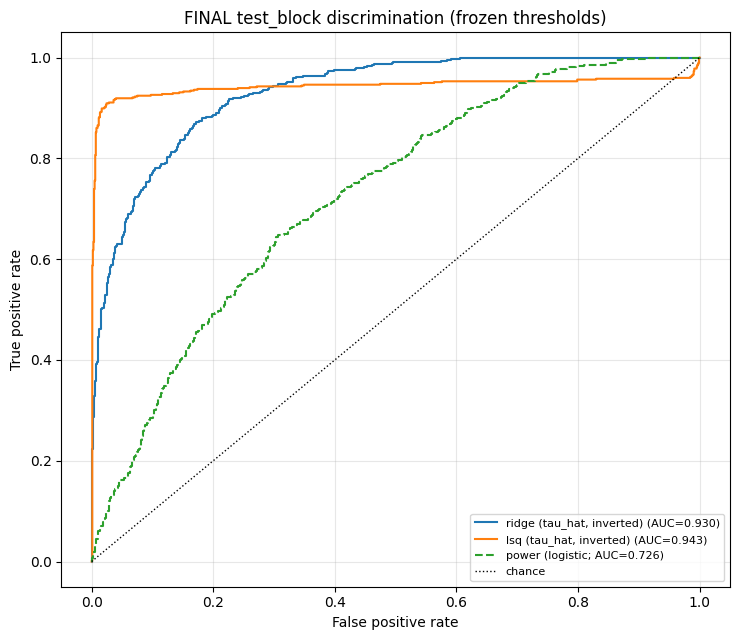


Low-FPR operating-point results (conditional, from Section 7):
  ridge   : TPR=0.486  FPR=0.016
  lsq     : TPR=0.879  FPR=0.012
  power   : TPR=0.054  FPR=0.010


In [10]:
# ---------------------------------------------------------------------------
# 9. AUC + operating-point results
# ---------------------------------------------------------------------------
test_passing = [r for r in test_records if r['stage1_pass']]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
auc_final = {}
for name, score_key, higher_is_anomalous in [
        ('ridge (tau_hat, inverted)', 'tau_hat_ridge', False),
        ('lsq (tau_hat, inverted)', 'tau_hat_lsq', False)]:
    subset = [r for r in test_passing if r.get(score_key) is not None]
    y_true = np.array([r['is_anomalous'] for r in subset]).astype(int)
    scores = np.array([r[score_key] for r in subset])
    if not higher_is_anomalous:
        scores = -scores
    if len(np.unique(y_true)) < 2:
        print(f"{name}: skipped (one class only)")
        continue
    auc = roc_auc_score(y_true, scores)
    auc_final[name] = auc
    fpr_c, tpr_c, _ = roc_curve(y_true, scores)
    ax.plot(fpr_c, tpr_c, label=f'{name} (AUC={auc:.3f})')
    print(f"{name:28s}: test_block AUC={auc:.3f}  (n={len(subset)})")

power_subset = [r for r in test_passing if r.get('total_power_raw') is not None]
y_true_power = np.array([r['is_anomalous'] for r in power_subset]).astype(int)
power_vals = np.array([r['total_power_raw'] for r in power_subset])
power_probs = power_clf.predict_proba(power_vals.reshape(-1, 1))[:, 1]

auc_power_pos = roc_auc_score(y_true_power, power_vals)
auc_power_neg = roc_auc_score(y_true_power, -power_vals)
auc_power_logistic = roc_auc_score(y_true_power, power_probs)
auc_final['power (AUC(power))'] = auc_power_pos
auc_final['power (AUC(-power))'] = auc_power_neg
auc_final['power (AUC(logistic))'] = auc_power_logistic

print(f"\nAUC(power)              = {auc_power_pos:.3f}")
print(f"AUC(-power)             = {auc_power_neg:.3f}")
print(f"AUC(logistic)           = {auc_power_logistic:.3f}")

fpr_p, tpr_p, _ = roc_curve(y_true_power, power_probs)
ax.plot(fpr_p, tpr_p, label=f'power (logistic; AUC={auc_power_logistic:.3f})', ls='--')
ax.plot([0, 1], [0, 1], 'k:', lw=1, label='chance')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('FINAL test_block discrimination (frozen thresholds)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_final_roc.pdf'))
plt.show()

# Operating-point TPR/FPR for all three methods (from Section 7, restated here alongside AUC)
op_point = {row['method']: (row['tpr'], row['fpr']) for row in final_metrics if row['mode'] == 'conditional'}
print("\nLow-FPR operating-point results (conditional, from Section 7):")
for name, (tpr, fpr) in op_point.items():
    print(f"  {name:8s}: TPR={tpr:.3f}  FPR={fpr:.3f}")


## 10. Comparison against `stage2_val` held-out validation (Notebook 4.5)

Reported as-is. Per rule 9: if `test_block` performance is worse than validation, this section states
that plainly and does not attempt to explain it away or trigger any re-tuning.


In [11]:
# ---------------------------------------------------------------------------
# 10. Comparison against Notebook 4.5's held-out (stage2_val) numbers
# ---------------------------------------------------------------------------
# Notebook 4.5 held-out reference values (hardcoded from that notebook's confirmed run -- not re-derived
# here, since stage2_val itself is not touched in this notebook).
STAGE2_VAL_REFERENCE = {
    'ridge_auc': 0.915, 'lsq_auc': 0.934,
    'ridge_tpr_conditional': 0.472, 'ridge_fpr_conditional': 0.010,
    'lsq_tpr_conditional': 0.835, 'lsq_fpr_conditional': 0.017,
    'power_operating_tpr_conditional': 0.043, 'power_operating_fpr_conditional': 0.012,
    'tau_1ms_flag_rate': 0.704, 'tau_3ms_flag_rate': 0.242,
}

test_ridge_auc = auc_final.get('ridge (tau_hat, inverted)', float('nan'))
test_lsq_auc = auc_final.get('lsq (tau_hat, inverted)', float('nan'))
test_ridge_tpr, test_ridge_fpr = op_point.get('ridge', (float('nan'), float('nan')))
test_lsq_tpr, test_lsq_fpr = op_point.get('lsq', (float('nan'), float('nan')))
test_power_tpr, test_power_fpr = op_point.get('power', (float('nan'), float('nan')))

print(f"{'metric':32s} {'stage2_val (Notebook 4.5)':>26s} {'test_block (this notebook)':>27s}")
comparison_rows = [
    ('ridge AUC', STAGE2_VAL_REFERENCE['ridge_auc'], test_ridge_auc),
    ('lsq AUC', STAGE2_VAL_REFERENCE['lsq_auc'], test_lsq_auc),
    ('ridge conditional TPR', STAGE2_VAL_REFERENCE['ridge_tpr_conditional'], test_ridge_tpr),
    ('ridge conditional FPR', STAGE2_VAL_REFERENCE['ridge_fpr_conditional'], test_ridge_fpr),
    ('lsq conditional TPR', STAGE2_VAL_REFERENCE['lsq_tpr_conditional'], test_lsq_tpr),
    ('lsq conditional FPR', STAGE2_VAL_REFERENCE['lsq_fpr_conditional'], test_lsq_fpr),
    ('power_operating conditional TPR', STAGE2_VAL_REFERENCE['power_operating_tpr_conditional'], test_power_tpr),
    ('power_operating conditional FPR', STAGE2_VAL_REFERENCE['power_operating_fpr_conditional'], test_power_fpr),
    ('tau=1ms flag rate', STAGE2_VAL_REFERENCE['tau_1ms_flag_rate'], per_tau_rates['ridge'][1]),
    ('tau=3ms flag rate', STAGE2_VAL_REFERENCE['tau_3ms_flag_rate'], per_tau_rates['ridge'][3]),
]
for metric, val_ref, val_test in comparison_rows:
    delta = val_test - val_ref
    flag = '' if abs(delta) < 0.10 else '  <-- notable difference'
    print(f"{metric:32s} {val_ref:26.3f} {val_test:27.3f}{flag}")

print("\nReported as observed. Per project rule: no threshold or parameter in this notebook is adjusted")
print("in response to this comparison, regardless of direction or magnitude of any difference.")


metric                            stage2_val (Notebook 4.5)  test_block (this notebook)
ridge AUC                                             0.915                       0.930
lsq AUC                                               0.934                       0.943
ridge conditional TPR                                 0.472                       0.486
ridge conditional FPR                                 0.010                       0.016
lsq conditional TPR                                   0.835                       0.879
lsq conditional FPR                                   0.017                       0.012
power_operating conditional TPR                       0.043                       0.054
power_operating conditional FPR                       0.012                       0.010
tau=1ms flag rate                                     0.704                       0.736
tau=3ms flag rate                                     0.242                       0.237

Reported as observed. Per proje

## 11. Final consolidated summary — save all outputs


In [12]:
# ---------------------------------------------------------------------------
# 11. Final summary JSON
# ---------------------------------------------------------------------------
final_summary = {
    'frozen_config_used': FROZEN,
    'test_block_n_total': n_total,
    'test_block_n_stage1_pass': n_passed,
    'test_block_stage1_pass_rate': n_passed / n_total,
    'stage1_pass_rate_by_tau': {
        str(tau_ms): sum(r['stage1_pass'] for r in test_records if r['tau_ms'] == tau_ms) /
                     sum(1 for r in test_records if r['tau_ms'] == tau_ms)
        for tau_ms in TAU_GRID_MS
    },
    'conditional_and_endtoend_metrics': final_metrics,
    'per_tau_flag_rates': {name: {str(k): v for k, v in rates.items()}
                            for name, rates in per_tau_rates.items()},
    'auc_results': auc_final,
    'operating_point_results': {name: {'tpr': tpr, 'fpr': fpr} for name, (tpr, fpr) in op_point.items()},
    'comparison_to_stage2_val': [
        {'metric': m, 'stage2_val': v_ref, 'test_block': v_test, 'delta': v_test - v_ref}
        for m, v_ref, v_test in comparison_rows
    ],
}

with open(os.path.join(OUT_DIR, 'FINAL_SUMMARY.json'), 'w') as f:
    json.dump(final_summary, f, indent=2)

print(f"Saved -> {OUT_DIR}/FINAL_SUMMARY.json")
print("""
nb5_artifacts/
  test_block_records.json   # every sample: tau/SNR/Stage-1 result/tau_hat(s)/power (test_block only)
  plot_final_roc.pdf        # final ROC comparison, all methods
  FINAL_SUMMARY.json        # everything reported in this notebook, consolidated
""")
print("=" * 70)
print("FINAL EVALUATION COMPLETE.")
print("test_block has now been used, once, for evaluation only.")
print("No threshold, model, or hyperparameter in this project was changed based on its results.")
print("=" * 70)


Saved -> /content/drive/MyDrive/gw_postmerger/nb5_artifacts/FINAL_SUMMARY.json

nb5_artifacts/
  test_block_records.json   # every sample: tau/SNR/Stage-1 result/tau_hat(s)/power (test_block only)
  plot_final_roc.pdf        # final ROC comparison, all methods
  FINAL_SUMMARY.json        # everything reported in this notebook, consolidated

FINAL EVALUATION COMPLETE.
test_block has now been used, once, for evaluation only.
No threshold, model, or hyperparameter in this project was changed based on its results.


---

## This notebook is the final result. What follows is manuscript writing, not further experimentation.

The numbers in `FINAL_SUMMARY.json` are this project's reportable Stage-1/Stage-2 results. Per
`PROJECT_SPEC.md` Sec. 5 (forbidden claims) and Sec. 11 (frozen design), any manuscript text built on
this notebook must:

- Describe the Stage-1 claim exactly as stated in `PROJECT_SPEC.md` Sec. 10 (local time-frequency
  organization beyond total power -- not physical coherence).
- Report ridge and LSQ together, with the "strong ranking-level separation" vs. "strongest low-FPR
  operating-point recall" distinction intact.
- Report the power baseline with both its AUC and its operating-point TPR/FPR, not AUC alone.
- State plainly whether `test_block` performance matched, exceeded, or fell short of the `stage2_val`
  validation (Section 10 above) -- this is a result to report, not a discrepancy to resolve.
- Include the standing caveats that were never resolved and were never meant to be resolved by this
  notebook: single-mode toy waveform, L1-only, no CNN/AST-Mahalanobis comparison, band-leakage mechanism
  unconfirmed.
